In [49]:
import pandas as pd
import re
from functools import reduce
from scipy.stats import pearsonr
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import zscore
import matplotlib.pyplot as plt
import os
import glob
from scipy.stats import zscore

In [50]:
cyt_tmp22=['CCL26', 'IL16', 'IL1B', 'IL13', 'IL7', 'CCL13', 'CCL2', 'IL12A','IL15', 'VEGFA', 'CCL4', 'IL8', 'TNF', 'IL1A', 'CXCL10', 'IL10', 'IL6','LTA', 'CCL22', 'CCL3', 'IFNG', 'CCL17', 'CCL11']

In [51]:
tcga_features = pd.read_csv("/data/kumarr17/common_features_ver3.txt", header=None)
cyt_features = pd.read_csv("/data/kumarr17/common_cyt_nichenet_gulden_tcga.txt", header=None)
tcga_features_list=list(tcga_features[0])
cyt_features_list=cyt_tmp22

In [52]:
df_tcga=pd.read_csv("/data/kumarr17/merged_sample_mtx/TCGA_Merged_mRNA_Expression.tsv", index_col=0)
df_tcga_features=df_tcga[tcga_features_list]
df_tcga_cyt_col=df_tcga[cyt_features_list]

In [53]:
## predicting on this Ovarian dataset
gene_df=pd.read_csv("/data/kumarr17/6546658/Book2_gene_vs_sample.csv")
gene_df_v2=gene_df.drop(columns=['ensembl_gene_id','gene_biotype'])
gene_df_v3=gene_df_v2.set_index('hgnc_symbol').T
list4=list(gene_df_v3.columns)
gene_df_v4_prediction_cohort=gene_df_v3[tcga_features_list]

In [54]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# clear session
# -----------------------------
tf.keras.backend.clear_session()

# -----------------------------
# cytokines to predict
# -----------------------------
cyt_tmp = cyt_tmp22#cyt_of_interest

# -----------------------------
# TCGA training feature matrix
# -----------------------------
df_train_features = df_tcga_features

X_train_raw = df_train_features.values.astype("float32")

# optional row-wise z-score
X_train_raw = (X_train_raw - X_train_raw.mean(axis=1, keepdims=True)) / (
    X_train_raw.std(axis=1, keepdims=True) + 1e-8
)

# -----------------------------
# ovarian prediction cohort
X_test_raw = gene_df_v4_prediction_cohort.values.astype("float32")

# same row-wise z-score on prediction cohort
X_test_raw = (X_test_raw - X_test_raw.mean(axis=1, keepdims=True)) / (
    X_test_raw.std(axis=1, keepdims=True) + 1e-8
)

# -----------------------------
# feature scaling: fit on TCGA only
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")


# -----------------------------
# model architecture
# -----------------------------
def build_fcnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model


early_stop = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# train full TCGA model and predict ovarian cohort
# -----------------------------
pred_df_list = []

for cytokine_to_check in cyt_tmp:

    print("\n==============================")
    print(f"Cytokine: {cytokine_to_check}")
    print("==============================")

    y_train = df_tcga_cyt_col[[cytokine_to_check]].values.astype("float32")

    tf.keras.backend.clear_session()
    model = build_fcnn(X_train.shape[1])

    model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop]
    )

    y_pred = model.predict(X_test, verbose=0).ravel()

    pred_df_list.append(
        pd.DataFrame({
            "sample": gene_df_v4_prediction_cohort.index,
            "cytokine": cytokine_to_check,
            "predicted_activity": y_pred
        })
    )

# -----------------------------
# final prediction outputs
# -----------------------------
ovarian_pred_df = pd.concat(pred_df_list, axis=0).reset_index(drop=True)

ovarian_pred_matrix = ovarian_pred_df.pivot(
    index="sample",
    columns="cytokine",
    values="predicted_activity"
)

ovarian_pred_df.head()


Cytokine: CCL26

Cytokine: IL16

Cytokine: IL1B

Cytokine: IL13

Cytokine: IL7

Cytokine: CCL13

Cytokine: CCL2

Cytokine: IL12A

Cytokine: IL15

Cytokine: VEGFA

Cytokine: CCL4

Cytokine: IL8

Cytokine: TNF

Cytokine: IL1A

Cytokine: CXCL10

Cytokine: IL10

Cytokine: IL6

Cytokine: LTA

Cytokine: CCL22

Cytokine: CCL3

Cytokine: IFNG

Cytokine: CCL17

Cytokine: CCL11


,sample,cytokine,predicted_activity
0,G8,CCL26,56.635944
1,G10,CCL26,54.269764
2,G11,CCL26,44.960976
3,G15,CCL26,36.877712
4,G17,CCL26,53.909161


In [55]:
ovarian_pred_df

,sample,cytokine,predicted_activity
0,G8,CCL26,56.635944
1,G10,CCL26,54.269764
2,G11,CCL26,44.960976
3,G15,CCL26,36.877712
4,G17,CCL26,53.909161
...,...,...,...
800,G102,CCL11,-17.852314
801,G124,CCL11,72.168777
802,G136,CCL11,14.675422
803,G138,CCL11,301.375427


In [56]:
ovarian_pred_matrix = ovarian_pred_df.pivot(
    index='sample',
    columns='cytokine',
    values='predicted_activity'
)

ovarian_pred_matrix.head()

cytokine,CCL11,CCL13,CCL17,CCL2,CCL22,CCL26,CCL3,CCL4,CXCL10,IFNG,...,IL15,IL16,IL1A,IL1B,IL6,IL7,IL8,LTA,TNF,VEGFA
sample,,,,,,,,,,,,,,,,,,,,,
G10,19.372158,131.242645,-23.190800,4483.686523,76.817070,54.269764,320.105072,376.187012,1219.660522,0.013654,...,285.068024,770.225159,-2.538720,278.476532,1115.184814,173.194794,606.567810,17.256531,193.309448,-402.042786
G102,-17.852314,383.045349,-70.563019,2475.830322,78.140190,37.513535,304.912598,522.627441,1146.194214,-0.821239,...,464.259064,1977.687378,-52.442101,275.453766,167.885971,292.552429,572.083069,11.451819,94.451645,5497.872559
G11,15.563504,75.098854,-22.669880,7763.250000,82.317924,44.960976,96.158806,265.678101,409.506958,-3.129943,...,341.913055,524.822998,-31.703285,357.865387,1564.105469,183.376953,1148.919678,18.571413,49.190327,-505.621277
G124,72.168777,66.230103,-91.827469,593.387390,93.028725,26.878565,228.664291,81.539391,706.982239,-0.129284,...,193.678802,133.987930,0.567374,190.758072,34.103500,58.109543,948.277527,24.912560,56.812565,3425.785400
G136,14.675422,214.975006,-124.600410,593.617004,109.227440,13.444554,280.757965,293.784210,2163.031738,5.201454,...,437.987213,589.190491,-43.149269,169.194977,10.397299,84.863953,622.794922,32.073570,48.430531,2751.651367


In [57]:
protein_df

,IFNG,IL10,IL12A,IL13,IL1B,IL2,IL4,IL6,IL8,TNF,...,VEGFA,CCL11,CCL26,CXCL10,CCL2,CCL13,CCL22,CCL3,CCL4,CCL17
SAMPLE,,,,,,,,,,,,,,,,,,,,,
G35,1.051928,0.116605,0.407824,9.042875,2.134844,1.249389,0.077092,151.943453,13.052494,0.358956,...,35.988842,8.480602,8.776747,0.785050,258.346909,7.068865,25.536269,63.882361,38.283525,5.355748
G42,0.559970,3.976826,0.127768,8.095760,4.163027,3.579857,0.061644,99.233747,90.578985,0.137754,...,42.751647,5.110452,6.661326,1.826708,120.019327,5.553700,17.154290,37.986443,78.293908,4.484345
G88,0.080418,0.092583,0.228174,4.028620,0.661708,1.015040,0.051948,6.046641,3.441065,0.175355,...,79.924217,5.043980,0.951800,1.246406,28.675531,2.594421,11.181801,3.116173,7.676933,4.373939
G45,0.551280,0.190877,0.061762,12.874662,2.218976,2.538678,0.051983,7.681524,4.134651,0.073106,...,170.910660,9.003090,12.038673,1.602089,48.643260,6.883993,44.140683,13.680269,19.326290,5.984729
G93,1.359359,0.194446,0.000000,3.339900,1.833406,2.475525,0.000000,132.067797,8.872343,0.108672,...,22.545428,6.858037,3.447998,3.193353,37.793579,3.233636,9.372290,3.443991,8.247788,3.003710
G94,0.152249,5.284602,0.059890,8.890887,3.508412,2.178410,0.070227,373.003964,75.309635,0.054951,...,91.368707,8.503638,7.385667,35.472215,0.000000,7.343955,16.334423,9.097707,34.897032,5.581416
G72,0.240197,0.169075,0.102580,3.955117,0.469411,0.542245,0.007591,10.910149,2.646502,0.090499,...,27.403764,3.210091,2.344794,0.336650,4.045049,1.644712,4.262015,4.373521,10.278351,1.901290
G76,1.817463,0.121586,0.221929,6.582608,16.071147,4.346653,0.086344,361.520006,35.015866,0.231922,...,154.451131,1.203851,1.586633,0.157943,85.340448,1.769657,4.001118,4.757142,21.738939,3.114139
G43,1.650199,1.806173,0.065383,5.327997,5.330906,0.473035,0.064308,242.322706,18.012680,0.120408,...,21.360533,2.787392,1.301251,0.517677,405.261870,1.610316,8.328579,3.469844,3.241864,2.792885


In [58]:
protein_df=pd.read_csv("/data/kumarr17/6546658/Book1_protein_vs_sample.csv",index_col='SAMPLE')
df1_pred=ovarian_pred_matrix[cyt_tmp22]
df2_actual_gene=gene_df_v3[cyt_tmp22]
df3_actual_protein=protein_df[cyt_tmp22]


In [59]:
list1=list(df1_pred.index)
list2=list(df2_actual_gene.index)
list3=list(df3_actual_protein.index)

In [60]:
common = list(set(list1) & set(list2) & set(list3))

In [61]:
df1_pred_subset = df1_pred.loc[common]
df2_actual_gene_subset = df2_actual_gene.loc[common]
df3_actual_protein_subset = df3_actual_protein.loc[common]

In [62]:
act_gene_protein_corr_series = df2_actual_gene_subset.corrwith(df3_actual_protein_subset, axis=0)
act_gene_protein_corr_series

pred_gene_protein_corr_series = df1_pred_subset.corrwith(df3_actual_protein_subset, axis=0)
pred_gene_protein_corr_series

cytokine
CCL26    -0.496151
IL16      0.581700
IL1B      0.571874
IL13      0.580433
IL7       0.204259
CCL13     0.437994
CCL2      0.299323
IL12A    -0.028474
IL15     -0.051946
VEGFA     0.046491
CCL4      0.101611
IL8       0.625353
TNF      -0.221704
IL1A      0.400214
CXCL10    0.208125
IL10     -0.000177
IL6       0.729307
LTA       0.320011
CCL22     0.167980
CCL3      0.106011
IFNG      0.034389
CCL17    -0.058854
CCL11     0.057998
dtype: float64

In [63]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [64]:
x=list(act_gene_protein_corr_series)
y=list(pred_gene_protein_corr_series)  
df_act_pred_gene_protein=pd.DataFrame({'act_gene_protein':x,'pred_gene_protein':y},index=list(act_gene_protein_corr_series.index))

### protein analysis plot

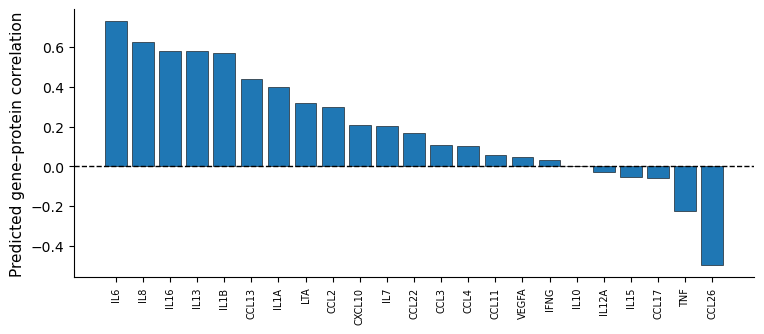

In [65]:
import matplotlib.pyplot as plt

df=df_act_pred_gene_protein
# Sort by predicted gene-protein correlation
df_sorted = df.sort_values(
    "pred_gene_protein",
    ascending=False
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 4))

# Bar plot
ax.bar(
    df_sorted.index.astype(str),
    df_sorted["pred_gene_protein"],
    edgecolor="black",
    linewidth=0.4
)

# Reference line at zero
ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Optional reference threshold
# ax.axhline(
#     y=0.3,
#     color="red",
#     linestyle="--",
#     linewidth=1
# )

# Axis labels
ax.set_xlabel("")

ax.set_ylabel(
    "Predicted gene–protein correlation",
    fontsize=11
)

# X-axis formatting
ax.tick_params(
    axis="x",
    rotation=90,
    labelsize=7
)

ax.tick_params(
    axis="y",
    labelsize=10
)

# Remove manuscript-unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No grid
ax.grid(False)

# Usually omit title for manuscript panel
# ax.set_title("Predicted gene–protein correlations")

# Give extra room for gene labels
fig.subplots_adjust(
    left=0.13,
    right=0.98,
    top=0.97,
    bottom=0.30
)

# Save as vector SVG
#fig.savefig(
#    "/data/kumarr17/cytokine_figure_directory/Predicted_gene_protein_correlation.svg",
#    format="svg",
#    bbox_inches="tight",
#    pad_inches=0.05
#)

plt.show()

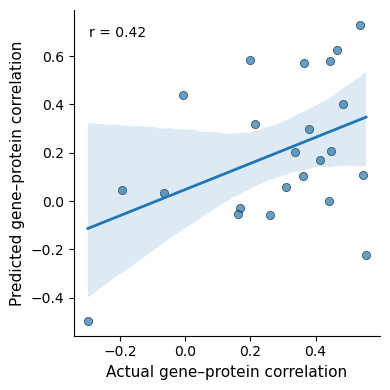

Pearson r = 0.422
P-value = 0.04477


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Data
x = df["act_gene_protein"]
y = df["pred_gene_protein"]

# Pearson correlation
r, p = pearsonr(x, y)

# Create figure
fig, ax = plt.subplots(figsize=(4, 4))

# Regression plot
sns.regplot(
    x=x,
    y=y,
    ax=ax,
    scatter_kws={
        "s": 35,
        "alpha": 0.7,
        "edgecolor": "black",
        "linewidth": 0.5
    },
    line_kws={
        "linewidth": 2
    }
)

# Axis labels
ax.set_xlabel(
    "Actual gene–protein correlation",
    fontsize=11
)

ax.set_ylabel(
    "Predicted gene–protein correlation",
    fontsize=11
)

# Correlation annotation
ax.text(
    0.05,
    0.95,
    f"r = {r:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# Manuscript formatting
ax.tick_params(axis="both", labelsize=10)

sns.despine(ax=ax)

ax.grid(False)

# Usually omit title for a manuscript panel
# ax.set_title("Gene vs Protein Correlation")

plt.tight_layout()

# Save as vector SVG
#fig.savefig(
#    "/data/kumarr17/cytokine_figure_directory/Actual_vs_predicted_gene_protein_correlation.svg",
#    format="svg",
#    bbox_inches="tight",
#    pad_inches=0.05
#)

plt.show()

print(f"Pearson r = {r:.3f}")
print(f"P-value = {p:.4g}")